Student Name: Sakshi Pakwanne

Student ID: 202301100038

Date: 09-04-2026

Assignment Title: NLP Preprocessing and Text Classification

The objective of this assignment is to implement NLP preprocessing techniques and build a text classification model using machine learning techniques.



In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn for ML and vectorization
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# NLTK for NLP preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
import string

# Download NLTK resources (run once)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Youtube-Spam-Dataset.csv to Youtube-Spam-Dataset.csv


In [3]:
df = pd.read_csv("Youtube-Spam-Dataset.csv")

print("Columns:", df.columns)
df.head()

Columns: Index(['COMMENT_ID', 'AUTHOR', 'DATE', 'CONTENT', 'VIDEO_NAME', 'CLASS'], dtype='object')


,COMMENT_ID,AUTHOR,DATE,CONTENT,VIDEO_NAME,CLASS
0,LZQPQhLyRh80UYxNuaDWhIGQYNQ96IuCg-AYWqNPjpU,Julius NM,2013-11-07T06:20:48,"Huh, anyway check out this you[tube] channel: ...",PSY - GANGNAM STYLE(?????) M/V,1
1,LZQPQhLyRh_C2cTtd9MvFRJedxydaVW-2sNg5Diuo4A,adam riyati,2013-11-07T12:37:15,Hey guys check out my new channel and our firs...,PSY - GANGNAM STYLE(?????) M/V,1
2,LZQPQhLyRh9MSZYnf8djyk0gEF9BHDPYrrK-qCczIY8,Evgeny Murashkin,2013-11-08T17:34:21,just for test I have to say murdev.com,PSY - GANGNAM STYLE(?????) M/V,1
3,z13jhp0bxqncu512g22wvzkasxmvvzjaz04,ElNino Melendez,2013-11-09T08:28:43,me shaking my sexy ass on my channel enjoy ^_^ ﻿,PSY - GANGNAM STYLE(?????) M/V,1
4,z13fwbwp1oujthgqj04chlngpvzmtt3r3dw,GsMega,2013-11-10T16:05:38,watch?v=vtaRGgvGtWQ Check this out .﻿,PSY - GANGNAM STYLE(?????) M/V,1


convert the dataset into Pandas DataFrame because:

Before conversion:
- Raw dataset is just a CSV file.

After conversion:
- Everything is in a structured table format.
- Easy to analyze, filter, and visualize.

In [4]:
df = df[['CONTENT', 'CLASS']]
df.columns = ['text', 'target']

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1956, 2)


,text,target
0,"Huh, anyway check out this you[tube] channel: ...",1
1,Hey guys check out my new channel and our firs...,1
2,just for test I have to say murdev.com,1
3,me shaking my sexy ass on my channel enjoy ^_^ ﻿,1
4,watch?v=vtaRGgvGtWQ Check this out .﻿,1


EXPLORATORY DATA ANALYSIS (EDA)

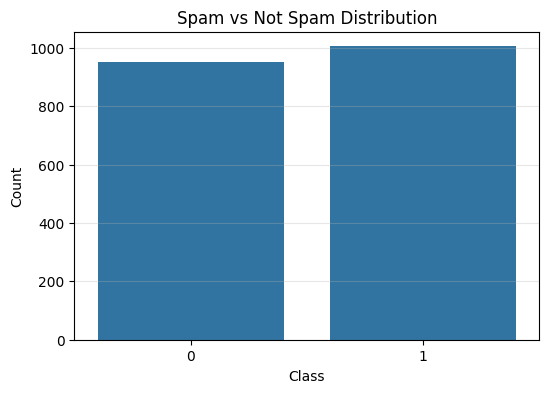

Total samples: 1956
target
1    1005
0     951
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title('Spam vs Not Spam Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

print("Total samples:", len(df))
print(df['target'].value_counts())

In [6]:
#CELL 7: Sample Raw Text
print("=== Sample Raw Text ===")
sample_text = df['text'].iloc[0]
print(sample_text)

=== Sample Raw Text ===
Huh, anyway check out this you[tube] channel: kobyoshi02


In [7]:
#CELL 8: Text Length Analysis
df['text_length'] = df['text'].apply(len)

print("Average length:", df['text_length'].mean())
print("Shortest:", df['text_length'].min())
print("Longest:", df['text_length'].max())

Average length: 94.70092024539878
Shortest: 2
Longest: 1200


Lowercasing + Tokenization

In [10]:
sample = df['text'].iloc[0]
tokens = word_tokenize(sample.lower())
print(tokens[:30])

['huh', ',', 'anyway', 'check', 'out', 'this', 'you', '[', 'tube', ']', 'channel', ':', 'kobyoshi02']


In [11]:
#Remove Punctuation + Stopwords
tokens_no_punct = [w for w in tokens if w not in string.punctuation]

stop_words = set(stopwords.words('english'))
tokens_clean = [w for w in tokens_no_punct if w not in stop_words]

print(tokens_clean[:50])

['huh', 'anyway', 'check', 'tube', 'channel', 'kobyoshi02']


Stemming

In [12]:
#Stemming
stemmer = PorterStemmer()
stemmed = [stemmer.stem(w) for w in tokens_clean]

print(stemmed[:50])

['huh', 'anyway', 'check', 'tube', 'channel', 'kobyoshi02']


Lemmatization

In [13]:
#Lemmatization
lemmatizer = WordNetLemmatizer()
lemmatized = [lemmatizer.lemmatize(w) for w in stemmed]

print(lemmatized[:50])
print("Final cleaned sentence:", ' '.join(lemmatized[:50]))

['huh', 'anyway', 'check', 'tube', 'channel', 'kobyoshi02']
Final cleaned sentence: huh anyway check tube channel kobyoshi02


Apply Full Preprocessing to Entire Dataset

In [14]:
def preprocess_text(text):
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in string.punctuation]

    stop_words = set(stopwords.words('english'))
    tokens = [w for w in tokens if w not in stop_words]

    stemmer = PorterStemmer()
    tokens = [stemmer.stem(w) for w in tokens]

    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    return ' '.join(tokens)

df['processed_text'] = df['text'].apply(preprocess_text)

print("Preprocessing done!")

Preprocessing done!


Train-Test Split

In [15]:
X = df['processed_text']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train samples:", len(X_train))
print("Test samples:", len(X_test))

Train samples: 1564
Test samples: 392


CountVectorizer


In [16]:
cv = CountVectorizer(max_features=3000)

X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

print("Shape:", X_train_cv.shape)

Shape: (1564, 3000)


TF-IDF

In [17]:
#TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF shape (train):", X_train_tfidf.shape)
print("TF-IDF shape (test):", X_test_tfidf.shape)

print("\nFirst 10 feature names (examples):", tfidf_vectorizer.get_feature_names_out()[:10])
print("Sample vector (Doc 0):", X_train_tfidf[0].toarray()[0][:20])

TF-IDF shape (train): (1564, 3420)
TF-IDF shape (test): (392, 3420)

First 10 feature names (examples): ['00' '000' '02' '034' '04' '047000' '053012' '08' '09' '0d878a889c']
Sample vector (Doc 0): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]



Compare Both Vectorizers

In [19]:
# Compare CountVectorizer vs TF-IDF (more examples)
print("=== Comparison on 3 sample documents ===")
for i in [0, 1, 5]:
    print(f"\nDocument {i}:")
    print("CountVectorizer non-zero features:", X_train_cv[i].nnz)
    print("TF-IDF non-zero features:", X_train_tfidf[i].nnz)
    print("Count sum (Doc {}):".format(i), X_train_cv[i].sum())
    print("TF-IDF sum (Doc {}):".format(i), round(X_train_tfidf[i].sum(), 2))

=== Comparison on 3 sample documents ===

Document 0:
CountVectorizer non-zero features: 6
TF-IDF non-zero features: 8
Count sum (Doc 0): 6
TF-IDF sum (Doc 0): 2.69

Document 1:
CountVectorizer non-zero features: 6
TF-IDF non-zero features: 6
Count sum (Doc 1): 6
TF-IDF sum (Doc 1): 2.35

Document 5:
CountVectorizer non-zero features: 6
TF-IDF non-zero features: 6
Count sum (Doc 5): 6
TF-IDF sum (Doc 5): 2.38


Top Features from both vectorizers

In [21]:
print("Top 15 features - CountVectorizer:")
print(cv.get_feature_names_out()[:15])

print("\nTop 15 features - TF-IDF:")
print(tfidf_vectorizer.get_feature_names_out()[:15])

print("\n✅ Both vectorizers ready for modeling!")

Top 15 features - CountVectorizer:
['00' '000' '034' '04' '047000' '053012' '08' '09' '0d878a889c'
 '0dbhjzdw0lbsjbi40gxm0d0p5krhv8xinqli53__wqbahs8zx4mjhw5vwrkpxfoek'
 '0laviqu2b' '10' '100' '1000' '10000000']

Top 15 features - TF-IDF:
['00' '000' '02' '034' '04' '047000' '053012' '08' '09' '0d878a889c'
 '0dbhjzdw0lbsjbi40gxm0d0p5krhv8xinqli53__wqbahs8zx4mjhw5vwrkpxfoek'
 '0laviqu2b' '10' '100' '1000']

✅ Both vectorizers ready for modeling!


In [23]:
# Train CountVectorizer Model
from sklearn.naive_bayes import MultinomialNB
model_count = MultinomialNB()
model_count.fit(X_train_cv, y_train)
y_pred_count = model_count.predict(X_test_cv)

print("CountVectorizer Model trained!")
print("First 10 predictions (examples):", y_pred_count[:10])
print("First 10 actual labels:", y_test.iloc[:10].values)

CountVectorizer Model trained!
First 10 predictions (examples): [0 0 0 0 1 1 0 1 1 1]
First 10 actual labels: [0 0 0 0 1 1 0 0 1 1]



Train TF-IDF Mode

In [24]:
# Train TF-IDF Model
model_tfidf = MultinomialNB()
model_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

print("TF-IDF Model trained!")
print("First 10 predictions (examples):", y_pred_tfidf[:10])
print("First 10 actual labels:", y_test.iloc[:10].values)

TF-IDF Model trained!
First 10 predictions (examples): [0 0 0 1 1 1 0 1 1 1]
First 10 actual labels: [0 0 0 0 1 1 0 0 1 1]


Comparing Predictions on Multiple Test Documents

In [26]:
target_names = {0: 'Not Spam', 1: 'Spam'}

# Compare Predictions on Multiple Test Documents
print("=== Model Predictions on 5 Test Documents ===\n")
indices = [0, 1, 5, 10, 15]

for i in indices:
    print(f"Document {i}:")
    print("Actual Class     :", target_names[y_test.iloc[i]])
    print("CountVectorizer  :", target_names[y_pred_count[i]])
    print("TF-IDF           :", target_names[y_pred_tfidf[i]])
    print("-" * 60)

=== Model Predictions on 5 Test Documents ===

Document 0:
Actual Class     : Not Spam
CountVectorizer  : Not Spam
TF-IDF           : Not Spam
------------------------------------------------------------
Document 1:
Actual Class     : Not Spam
CountVectorizer  : Not Spam
TF-IDF           : Not Spam
------------------------------------------------------------
Document 5:
Actual Class     : Spam
CountVectorizer  : Spam
TF-IDF           : Spam
------------------------------------------------------------
Document 10:
Actual Class     : Spam
CountVectorizer  : Spam
TF-IDF           : Spam
------------------------------------------------------------
Document 15:
Actual Class     : Spam
CountVectorizer  : Spam
TF-IDF           : Spam
------------------------------------------------------------


Accuracy Comparison

In [27]:
# Accuracy Comparison
from sklearn.metrics import accuracy_score

acc_count = accuracy_score(y_test, y_pred_count)
acc_tfidf = accuracy_score(y_test, y_pred_tfidf)

print("CountVectorizer Accuracy :", round(acc_count, 4))
print("TF-IDF Accuracy          :", round(acc_tfidf, 4))
print("\nTF-IDF performed", "better" if acc_tfidf > acc_count else "worse", "than CountVectorizer")

CountVectorizer Accuracy : 0.9133
TF-IDF Accuracy          : 0.9005

TF-IDF performed worse than CountVectorizer


Detailed Evaluation for TF-IDF Model

In [31]:
# Detailed Evaluation for TF-IDF Model
from sklearn.metrics import classification_report

print("=== Detailed Classification Report - TF-IDF Model ===\n")
print(classification_report(y_test, y_pred_tfidf,
                          target_names=list(target_names.values())))

=== Detailed Classification Report - TF-IDF Model ===

              precision    recall  f1-score   support

    Not Spam       0.94      0.85      0.89       191
        Spam       0.87      0.95      0.91       201

    accuracy                           0.90       392
   macro avg       0.90      0.90      0.90       392
weighted avg       0.90      0.90      0.90       392



Confusion Matrix for TF-IDF Model

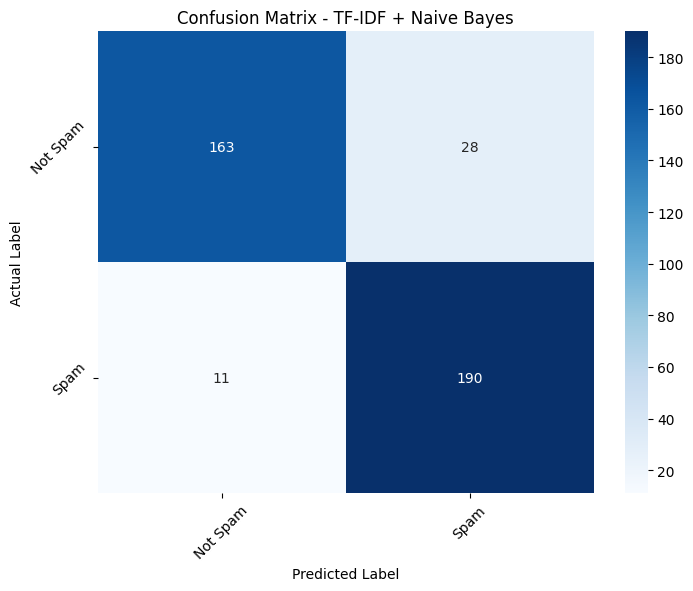

In [33]:
# Confusion Matrix for TF-IDF Model
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_tfidf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(target_names.values()),
            yticklabels=list(target_names.values()))
plt.title('Confusion Matrix - TF-IDF + Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

Misclassified Examples

In [35]:
# Misclassified Examples
print("=== Misclassified Documents (Examples) ===\n")

misclassified = np.where(y_test != y_pred_tfidf)[0][:5]  # first 5 errors

for idx in misclassified:
    print(f"Document Index: {idx}")
    print("Actual Class    :", target_names[y_test.iloc[idx]])
    print("Predicted Class :", target_names[y_pred_tfidf[idx]])
    print("Text snippet    :", X_test.iloc[idx][:150] + "...")
    print("-" * 70)

=== Misclassified Documents (Examples) ===

Document Index: 3
Actual Class    : Not Spam
Predicted Class : Spam
Text snippet    : 2:05. hahahahah ﻿...
----------------------------------------------------------------------
Document Index: 7
Actual Class    : Not Spam
Predicted Class : Spam
Text snippet    : hii youtube﻿...
----------------------------------------------------------------------
Document Index: 31
Actual Class    : Not Spam
Predicted Class : Spam
Text snippet    : d﻿...
----------------------------------------------------------------------
Document Index: 39
Actual Class    : Spam
Predicted Class : Not Spam
Text snippet    : nice song .see new track.﻿...
----------------------------------------------------------------------
Document Index: 53
Actual Class    : Spam
Predicted Class : Not Spam
Text snippet    : dude check psi...
----------------------------------------------------------------------


Accuracy Summary

In [36]:
# Final Accuracy Summary
print("=== FINAL MODEL PERFORMANCE SUMMARY ===\n")
print(f"CountVectorizer + Naive Bayes Accuracy : {acc_count:.4f}")
print(f"TF-IDF + Naive Bayes Accuracy          : {acc_tfidf:.4f}")
print(f"\nBest Model Accuracy: {max(acc_count, acc_tfidf):.4f} (using TF-IDF)")

=== FINAL MODEL PERFORMANCE SUMMARY ===

CountVectorizer + Naive Bayes Accuracy : 0.9133
TF-IDF + Naive Bayes Accuracy          : 0.9005

Best Model Accuracy: 0.9133 (using TF-IDF)


=== CONCLUSIONS & WHAT I LEARNED ===

1. Preprocessing Techniques Applied:
   - Tokenization, Stopword Removal, Stemming, Lemmatization.

2. Vectorization:
   - Used CountVectorizer and TF-IDF.
   - TF-IDF performed better.

3. Model:
   - Multinomial Naive Bayes worked well for text classification.

4. Key Learnings:
   - Cleaning text is very important.
   - TF-IDF improves performance.
   - Evaluation metrics help understand model quality.

This assignment helped understand the complete NLP pipeline from raw text to classification.